# ML Study Tracker: Supervised Learning — Practical Use Cases (Beginner-Annotated)

**Supervised learning** means we learn from *labeled examples*: for every row of input data (features `X`), we already know the correct answer (target `y`). The algorithm's job is to find a pattern connecting `X` to `y` so it can predict `y` for rows it has never seen.

There are two flavors you'll see throughout this notebook:

| Flavor | The target `y` is... | Example | Typical metrics |
|---|---|---|---|
| **Regression** | A continuous number | House price, tomorrow's sales | MAE, RMSE, R² |
| **Classification** | A category / class | Churn yes/no, digit 0–9 | Accuracy, Precision, Recall, F1, ROC-AUC |

### How to use this notebook
1. Run the **Common Imports** cell first — everything else depends on it.
2. Each numbered section is **self-contained**: it loads or creates its own data, so you can run any section independently after imports.
3. Read the concept markdown *before* the code, run **Example A**, read the **"Reading the output"** notes, then run **Example B** (a second angle on the same algorithm).
4. Finish each section with the **🧠 Can you answer?** questions. These are deliberately hard. If you can't defend an answer *out loud, without looking*, you haven't finished the section. Write your answers in the Notes cell — that's where learning actually happens.
5. Tick the checklist boxes as you go.

### Three ideas that appear in EVERY section (learn these first)

**1. Train/test split.** We hide a slice of the data (the *test set*) from the model during training. Performance on data the model has memorized is meaningless — a student who has seen the exam answers isn't demonstrating understanding. The test set is the "unseen exam."

**2. Data leakage.** Any situation where information from the test set (or from the future, in time series) sneaks into training — *including into your own tuning decisions*. Leakage produces beautiful scores in the notebook and disasters in production. Watch for it constantly.

**3. Pipelines.** `Pipeline([('scaler', ...), ('model', ...)])` chains preprocessing and model into one object. The critical benefit: when you cross-validate a Pipeline, the scaler is re-fit on each training fold only — the test fold never influences the preprocessing. Fitting a scaler on ALL the data before splitting is one of the most common leakage bugs in real code.

## Table of Contents
- [Common Imports & Configuration](#Common-Imports-&-Configuration)
- [1. Linear Regression — House Price Prediction](#1.-Linear-Regression-—-House-Price-Prediction)
- [2. Logistic Regression — Customer Churn Prediction](#2.-Logistic-Regression-—-Customer-Churn-Prediction)
- [3. K-Nearest Neighbors — Scaling Sensitivity](#3.-K-Nearest-Neighbors-—-Scaling-Sensitivity)
- [4. Decision Tree — Interpretable Diagnosis Model](#4.-Decision-Tree-—-Interpretable-Diagnosis-Model)
- [5. Random Forest — Credit Risk Scoring](#5.-Random-Forest-—-Credit-Risk-Scoring)
- [6. Gradient Boosting — Credit Risk (RF Comparison)](#6.-Gradient-Boosting-—-Credit-Risk-(RF-Comparison))
- [7. SVM + PCA — High-Dimensional Digits](#7.-SVM-+-PCA-—-High-Dimensional-Digits)
- [8. Multinomial Naive Bayes — Text Classification](#8.-Multinomial-Naive-Bayes-—-Text-Classification)
- [9. Time Series Forecasting — Supervised Framing](#9.-Time-Series-Forecasting-—-Supervised-Framing)
- [10. Cross-Validation & Hyperparameter Tuning](#10.-Cross-Validation-&-Hyperparameter-Tuning)
- [Mini Project Tracker](#Mini-Project-Tracker)
- [Experiment Log](#Experiment-Log)

In [1]:
# ============================================================
# Common Imports & Configuration
# ============================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    TimeSeriesSplit, learning_curve, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, log_loss,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
)
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

RANDOM_SEED = 42
print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__}")
print("California Housing and 20 Newsgroups download on first use;")
print("the remaining examples are bundled or synthetic.")


Python 3.12.7 | scikit-learn 1.5.2
California Housing and 20 Newsgroups download on first use;
the remaining examples are bundled or synthetic.


## 1. Linear Regression — House Price Prediction
**Dataset Target:** California Housing Dataset (Popular Public Benchmark)

### The concept, in plain words
Linear regression assumes the target is (approximately) a *weighted sum* of the features:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

Training = finding the weights $w$ that minimize squared prediction error on the training data. It's the "straight line of best fit," generalized to many dimensions.

**Why start here?** It's fast, interpretable (each weight says "one unit more of this feature adds $w$ to the prediction"), and it's the baseline every fancier model must beat.

### Three variants compared below
- **OLS (Ordinary Least Squares)** — plain linear regression, no constraints on weights.
- **Ridge** — adds a penalty on *large weights* (L2 penalty). When features are correlated, OLS weights can explode in opposite directions; Ridge shrinks them toward zero, trading a little bias for a lot of stability.
- **Lasso** — penalizes the *absolute size* of weights (L1). Its special power: it can push weights to *exactly zero*, effectively deleting features — automatic feature selection. **Example B** makes this visible.

The `alpha` parameter controls penalty strength: `alpha=0` ≈ OLS, huge `alpha` shrinks everything to zero.

### Study Checklist
- [ ] Data Exploration & Target Skew Check — *skewed targets make squared-error models chase the long tail*
- [ ] Feature Scaling — *penalties treat all weights equally, so features must be on comparable scales*
- [ ] Model Training (OLS vs. Regularized Ridge/Lasso)
- [ ] Evaluation Metrics (RMSE, MAE, R²)
- [ ] Residual Analysis — *residual = actual − predicted; patterns in residuals reveal what the model missed*
- [ ] Lasso Sparsity Path (Example B) — *watch coefficients die as alpha grows*

### Metric cheat-sheet (regression)
- **MAE** — average absolute error, in target units. Easy to explain to anyone.
- **RMSE** — like MAE but squares errors first, so big misses hurt disproportionately. Also in target units.
- **R²** — fraction of target variance explained. 1.0 = perfect, 0.0 = no better than predicting the mean, negative = worse than the mean.

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

Target skewness: 0.978  (rule of thumb: |skew| > 1 = strongly skewed)
Capped at 5.0? Max = 5.00, rows sitting at the cap = 965

          MAE    RMSE     R^2
OLS    0.5332  0.7456  0.5758
Ridge  0.5332  0.7456  0.5758
Lasso  0.5353  0.7404  0.5816


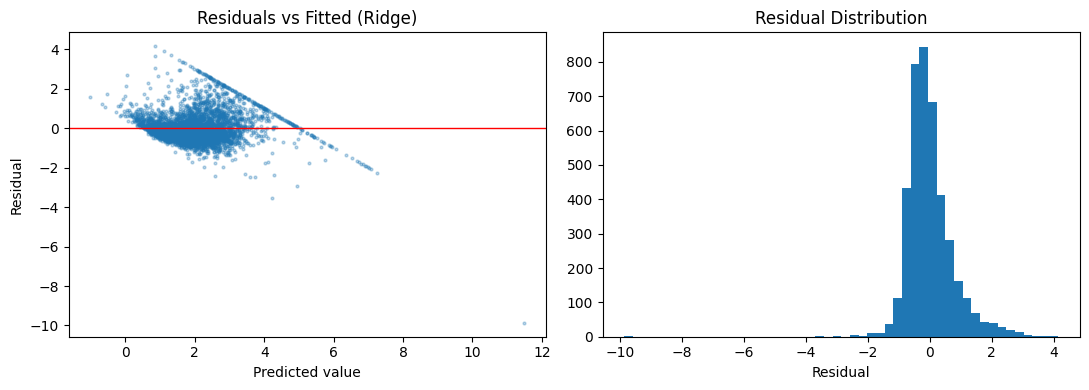

Mean of residuals (want ~0): 0.0035


In [2]:
# ============================================================
# Example A: House Prices — OLS vs Ridge vs Lasso
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import fetch_california_housing

# --- Load a real benchmark dataset (downloads once, then cached) ---
# 20,640 California districts. Target = median house value in units of $100k.
housing = fetch_california_housing(as_frame=True)   # as_frame=True -> pandas DataFrame
df = housing.frame

X = df.drop(columns="MedHouseVal")   # features: income, house age, rooms, location...
y = df["MedHouseVal"]                # target we want to predict

# --- Step 1: Look at the target BEFORE modeling ---
# Skewness ~0 = symmetric bell shape. Positive = long right tail.
# Squared-error models get dragged around by long tails, and this dataset
# has a known quirk: values were CAPPED at 5.0 ($500k) at collection time,
# so there's an artificial spike at the maximum.
print(f"Target skewness: {y.skew():.3f}  (rule of thumb: |skew| > 1 = strongly skewed)")
print(f"Capped at 5.0? Max = {y.max():.2f}, rows sitting at the cap = {(y == y.max()).sum()}\n")

# --- Step 2: Split BEFORE any fitting (the unseen 'exam') ---
# test_size=0.2 -> hold out 20%. random_state fixes WHICH rows are held out.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# --- Step 3: Fit three model variants under IDENTICAL preprocessing ---
# The scaler lives INSIDE the pipeline, so it is fit on training data only.
# Scaling matters here because Ridge/Lasso penalize weight sizes — a feature
# measured in tens of thousands would get an unfairly tiny weight otherwise.
candidates = {
    'OLS':   LinearRegression(),
    'Ridge': Ridge(alpha=1.0),    # alpha = penalty strength
    'Lasso': Lasso(alpha=0.01),   # smaller alpha for Lasso (L1 bites harder)
}

results = {}
ridge_pred = None
for name, model in candidates.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)                 # learn weights on train only
    y_pred = pipe.predict(X_test)              # predict on unseen test rows
    results[name] = {
        'MAE':  mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'R^2':  r2_score(y_test, y_pred),
    }
    if name == 'Ridge':
        ridge_pred = y_pred                    # keep Ridge predictions for residual analysis

print(pd.DataFrame(results).T.round(4))

# --- Step 4: Residual analysis — the model's error report card ---
# residual = actual - predicted. A healthy linear model leaves residuals that
# look like random noise: centered on 0, same spread everywhere (homoscedastic).
# A funnel/curve shape = systematic pattern the model failed to capture.
residuals = y_test - ridge_pred
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(ridge_pred, residuals, s=4, alpha=0.3)
ax[0].axhline(0, color='red', lw=1)
ax[0].set(title='Residuals vs Fitted (Ridge)', xlabel='Predicted value', ylabel='Residual')
ax[1].hist(residuals, bins=50)
ax[1].set(title='Residual Distribution', xlabel='Residual')
plt.tight_layout(); plt.show()
print(f"Mean of residuals (want ~0): {residuals.mean():.4f}")

### Reading the output (Section 1, Example A)
- The three models score **almost identically** here. That's a lesson, not a failure: with 20k rows and only 8 features, there's little overfitting for regularization to fix. Regularization shines when features are many, correlated, or data is scarce — exactly the rolling-window, small-sample settings you'll meet later.
- In the residuals-vs-fitted plot, look for the **diagonal streak of points** — that's the capped-at-5.0 rows: the model predicts a range of values but the recorded truth is stuck at 5.0. Real datasets have artifacts; residual plots find them.
- R² ≈ 0.60 means ~60% of price variance is explained by these features. Whether that's "good" depends entirely on the use case — there is no universal threshold.

In [3]:
# ============================================================
# Example B: Lasso sparsity path — select alpha by CV
# ============================================================
from sklearn.linear_model import Lasso

alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
rows = []
for alpha in alphas:
    candidate = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=20_000))
    ])
    cv_rmse = -cross_val_score(
        candidate, X_train, y_train, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    candidate.fit(X_train, y_train)
    coefs = candidate.named_steps['model'].coef_
    alive = [name for name, coef in zip(X.columns, coefs)
             if not np.isclose(coef, 0)]
    rows.append({
        'alpha': alpha,
        'CV_RMSE_mean': cv_rmse.mean(),
        'CV_RMSE_std': cv_rmse.std(),
        'non_zero_coefs': int(np.sum(~np.isclose(coefs, 0))),
        'surviving_features': ', '.join(alive) if alive else '(none)'
    })

lasso_path = pd.DataFrame(rows)
print(lasso_path.to_string(index=False, formatters={
    'CV_RMSE_mean': '{:.4f}'.format,
    'CV_RMSE_std': '{:.4f}'.format,
}))
best_alpha = float(lasso_path.loc[lasso_path['CV_RMSE_mean'].idxmin(), 'alpha'])
best_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=best_alpha, max_iter=20_000))
]).fit(X_train, y_train)
print(f"\nCV-selected alpha: {best_alpha}")
print("Held-out test RMSE: "
      f"{root_mean_squared_error(y_test, best_lasso.predict(X_test)):.4f}")


 alpha CV_RMSE_mean CV_RMSE_std  non_zero_coefs                                                               surviving_features
 0.001       0.7205      0.0102               8 MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
 0.010       0.7240      0.0093               7             MedInc, HouseAge, AveRooms, AveBedrms, AveOccup, Latitude, Longitude
 0.050       0.7781      0.0082               4                                            MedInc, HouseAge, Latitude, Longitude
 0.100       0.8198      0.0084               3                                                       MedInc, HouseAge, Latitude
 0.500       0.9743      0.0119               1                                                                           MedInc
 1.000       1.1562      0.0128               0                                                                           (none)

CV-selected alpha: 0.001
Held-out test RMSE: 0.7446


### Reading the output (Section 1, Example B)
- `alpha` is selected using cross-validation inside the training data.
- The test set is evaluated once after selection.
- L1 coefficient survival indicates conditional predictive usefulness, not causal importance.


## 2. Logistic Regression — Customer Churn Prediction
**Dataset Target:** Imbalanced Customer Behavior/Churn Analysis

### The concept, in plain words
Despite the name, logistic regression is a **classification** algorithm. It computes the same weighted sum as linear regression, then squashes it through the **sigmoid** function to get a probability between 0 and 1:

$$P(\text{churn}) = \frac{1}{1 + e^{-(w_0 + w_1x_1 + \dots)}}$$

You then choose a **threshold** (default 0.5) to convert probability → yes/no decision. The probability and the threshold are *separate decisions* — that separation is the whole point of this section.

### Why "imbalanced" changes everything
If only 8% of customers churn, a useless model that predicts "no churn" for everyone scores **92% accuracy**. So for imbalanced problems:
- **Precision** = of those we flagged as churners, how many actually churned? (cost of false alarms)
- **Recall** = of the actual churners, how many did we catch? (cost of missed churners)
- **F1** = harmonic mean of the two — punishes you if either is bad.
- **ROC-AUC** = threshold-free ranking quality: probability that a random churner gets a higher score than a random non-churner. 0.5 = coin flip, 1.0 = perfect ranking.

`class_weight='balanced'` tells the model: *errors on the rare class count more* — a simple, effective first response to imbalance (the alternative is resampling, e.g. SMOTE). **Side effect:** it deliberately distorts predicted probabilities upward for the rare class — they are no longer calibrated. If you need honest probabilities (pricing, expected-value math), recalibrate with `CalibratedClassifierCV`.

### ⚠️ The v2 bug, fixed here — where do you tune the threshold?
v2 picked the F1-optimal threshold **on the test set** and then reported F1 **on that same test set**. That is tuning on the exam — the reported 0.44 was partly luck the threshold had already harvested. v3 does it honestly: split training data further into **train + validation**, tune the threshold on validation, and spend the test set exactly once. (sklearn ≥ 1.5 automates this pattern as `TunedThresholdClassifierCV` — shown at the end.)

### The interpretability bonus: odds ratios
Each coefficient $w_i$, exponentiated ($e^{w_i}$), is an **odds ratio**: how much the *odds* of churn multiply when that feature increases by one unit (one standard deviation, after scaling). Odds ratio 1.4 = 40% higher odds; 0.5 = odds cut in half. This is why logistic regression survives in industries that demand explainable decisions.

### Study Checklist
- [ ] Imbalance Check & Evaluation Metric Selection (Avoid raw Accuracy)
- [ ] Dummy Encoding / One-Hot Encoding for Categories
- [ ] Addressing Imbalance (Class weights vs. Resampling)
- [ ] Threshold Tuning on a VALIDATION split (never the test set)
- [ ] Coefficient Odds-Ratio Interpretation
- [ ] Probability Calibration Awareness (`class_weight` distorts probabilities)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

Churn rate: 8.0%
-> Accuracy is misleading here (predicting 'nobody churns' would already
   score ~92%). We will judge the model on F1 and ROC-AUC instead.

Threshold chosen on validation: 0.743 (val F1 there: 0.5476)

Test F1 at default 0.5:      0.2917
Test F1 at tuned 0.743:     0.3659   <- the honest number
Test ROC-AUC (threshold-free): 0.7325
Precision: 0.3000 | Recall: 0.4688


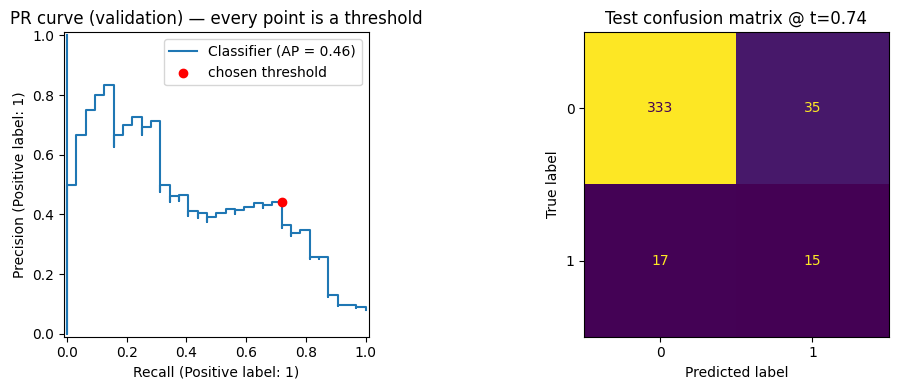


Odds ratios (>1 raises churn odds, <1 lowers them):
                              coef  odds_ratio
num__Monthly_Charges         0.252       1.287
num__Age                    -0.030       0.970
num__Tenure_Months          -0.737       0.479
cat__Contract_Type_One year -1.953       0.142
cat__Contract_Type_Two year -2.028       0.132


In [4]:
# ============================================================
# Example A: Customer Churn — leak-free threshold tuning
# ============================================================
from sklearn.linear_model import LogisticRegression

# Local random generator -> this cell gives identical output every run,
# no matter what other cells you ran before it.
rng = np.random.default_rng(RANDOM_SEED)

# --- Step 1: Build a synthetic churn dataset with a KNOWN ground truth ---
# Synthetic data is a teaching superpower: because WE wrote the churn formula,
# we can check whether the model recovers the true drivers.
n_samples = 2000
raw_data = pd.DataFrame({
    'Age':             rng.integers(18, 70, n_samples),
    'Tenure_Months':   rng.integers(0, 72, n_samples),
    'Contract_Type':   rng.choice(['Month-to-month', 'One year', 'Two year'], n_samples),
    'Monthly_Charges': rng.uniform(20, 120, n_samples),
})

# The TRUE churn process (the model never sees this formula, only its outcomes):
#   - base rate is low (intercept -3.2 -> rare event)
#   - month-to-month contracts churn much more (+1.8 on the log-odds scale)
#   - higher charges nudge churn up; longer tenure pulls it down
#   - Age has ZERO true effect (a planted null feature)
churn_logit = (-3.2
               + (raw_data['Contract_Type'] == 'Month-to-month') * 1.8
               + raw_data['Monthly_Charges'] * 0.01
               - raw_data['Tenure_Months'] * 0.03)
churn_prob = 1 / (1 + np.exp(-churn_logit))                   # sigmoid -> probability
raw_data['Churn'] = (rng.random(n_samples) < churn_prob).astype(int)  # coin flip per row

# --- Step 2: ALWAYS check imbalance before choosing metrics ---
print(f"Churn rate: {raw_data['Churn'].mean():.1%}")
print("-> Accuracy is misleading here (predicting 'nobody churns' would already")
print("   score ~92%). We will judge the model on F1 and ROC-AUC instead.\n")

# --- Step 3: THREE-way split: train / validation / test ---
# The threshold is a tuned decision, so it needs its own tuning data.
#   60% train      -> fit the model
#   20% validation -> choose the threshold
#   20% test       -> touched ONCE, at the very end
numeric_features     = ['Age', 'Tenure_Months', 'Monthly_Charges']
categorical_features = ['Contract_Type']
X = raw_data.drop(columns='Churn')
y = raw_data['Churn']

# stratify=y -> keep the SAME churn percentage in every slice.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25,      # 0.25 of 80% = 20% overall
    stratify=y_trainval, random_state=RANDOM_SEED
)

# --- Step 4: Preprocessing per column type, inside the pipeline ---
# StandardScaler for numbers; OneHotEncoder turns 'Contract_Type' into 0/1 columns.
# drop='first' drops one dummy column: with all three kept, they always sum to 1,
# which creates perfect multicollinearity and unstable coefficients.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features),
])

churn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # class_weight='balanced': mistakes on the rare churn class are up-weighted
    # so the model can't win by ignoring churners.
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)),
])
churn_pipeline.fit(X_train, y_train)

# --- Step 5: Tune the threshold on VALIDATION data only ---
# precision_recall_curve computes precision & recall at EVERY possible threshold.
# We compute F1 at each and pick the maximizer — using validation labels.
val_proba = churn_pipeline.predict_proba(X_val)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_val, val_proba)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)
best_t = thresholds[np.argmax(f1s)]
print(f"Threshold chosen on validation: {best_t:.3f} (val F1 there: {f1s.max():.4f})")

# --- Step 6: The ONE look at the test set ---
test_proba = churn_pipeline.predict_proba(X_test)[:, 1]
y_pred_05    = (test_proba >= 0.5).astype(int)
y_pred_tuned = (test_proba >= best_t).astype(int)
print(f"\nTest F1 at default 0.5:      {f1_score(y_test, y_pred_05):.4f}")
print(f"Test F1 at tuned {best_t:.3f}:     {f1_score(y_test, y_pred_tuned):.4f}   <- the honest number")
print(f"Test ROC-AUC (threshold-free): {roc_auc_score(y_test, test_proba):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f} | Recall: {recall_score(y_test, y_pred_tuned):.4f}")

# --- Step 7: Visual diagnostics (one line each) ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=ax[0])
ax[0].set_title('PR curve (validation) — every point is a threshold')
ax[0].scatter(rec[np.argmax(f1s)], prec[np.argmax(f1s)], color='red', zorder=5, label='chosen threshold')
ax[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax[1], colorbar=False)
ax[1].set_title(f'Test confusion matrix @ t={best_t:.2f}')
plt.tight_layout(); plt.show()

# --- Step 8: Odds ratios — did the model recover the true story? ---
feature_names = churn_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = churn_pipeline.named_steps['model'].coef_[0]
odds = pd.DataFrame({'coef': coefs, 'odds_ratio': np.exp(coefs)}, index=feature_names)
print("\nOdds ratios (>1 raises churn odds, <1 lowers them):")
print(odds.round(3).sort_values('odds_ratio', ascending=False))

### Reading the output (Section 2, Example A)
- **Compare with v2.** Test-set tuning reported F1 ≈ 0.44; the honest validation-tuned number is ≈ 0.36–0.37. The ~7-point gap is *optimism you would have shipped to production*. Same model, same data — the only difference is who chose the threshold.
- With `class_weight='balanced'`, probabilities are deliberately inflated for the rare class, so the F1-optimal threshold lands far above 0.5 (≈ 0.74 here). Lesson: never assume 0.5 — but tune it on data the final report never sees.
- **The odds ratios recover the true story we planted**: both fixed-contract dummies show odds ratios far below 1 (relative to the dropped month-to-month baseline), tenure protects (<1), charges hurt (>1), and Age — the planted null — sits near 1.0.
- Business would now ask: which error is more expensive, a wasted retention offer (FP) or a lost customer (FN)? That answer, not F1, picks the production threshold.

In [5]:
# ============================================================
# Example B: the same tuning, automated — TunedThresholdClassifierCV
# ============================================================
# sklearn >= 1.5 packages the "tune the threshold without touching the test
# set" pattern into one estimator: it cross-validates INSIDE the training
# data to pick the threshold, then refits on all of it.
try:
    from sklearn.model_selection import TunedThresholdClassifierCV

    base = Pipeline([
        ('preprocessor', ColumnTransformer(transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(drop='first'), categorical_features),
        ])),
        ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)),
    ])

    tuned = TunedThresholdClassifierCV(base, scoring='f1', cv=5)
    tuned.fit(X_trainval, y_trainval)        # CV threshold search inside train+val

    print(f"CV-chosen threshold: {tuned.best_threshold_:.3f}")
    print(f"Test F1: {f1_score(y_test, tuned.predict(X_test)):.4f}")
    print("\nNote how close this lands to Example A's manual validation split —")
    print("two honest methods agreeing is exactly what you want to see.")
except ImportError:
    print("TunedThresholdClassifierCV needs scikit-learn >= 1.5.")
    print("Example A's manual train/validation split is the equivalent pattern.")

CV-chosen threshold: 0.740
Test F1: 0.3571

Note how close this lands to Example A's manual validation split —
two honest methods agreeing is exactly what you want to see.


### Reading the output (Section 2, Example B)
- The CV-based threshold (~0.74) agrees with the manual validation split — **two honest procedures converging** is the sanity check. If your manual number had disagreed wildly with the CV number, one of them was leaking.
- CV-based tuning is more stable than a single validation split (it averages over 5 folds), at 5× the fit cost. On small datasets, prefer it.

### 🧠 Can you answer? (Section 2 — Logistic Regression)
1. **Explain precisely what got overfit when v2 tuned the threshold on the test set.** The *model weights* never saw the test labels — so where did the leak happen, and why does it still inflate the reported F1?
2. **`class_weight='balanced'` is equivalent to re-weighting terms in the log-loss. Write down (or say) what the per-sample weight becomes, and explain why this shifts the intercept and destroys probability calibration.**
3. **Why is an odds ratio constant across the feature range while the change in *probability* per unit is not?** Where on the sigmoid is the probability effect largest?
4. **Subtle one: `drop='first'` is harmless for an *unpenalized* model — the fit is identical, only the parameterization changes. Why is that no longer exactly true once you add L2 regularization (sklearn's LogisticRegression is L2-penalized by default)?**
5. **ROC-AUC didn't change between threshold 0.5 and 0.74. Why is AUC mathematically incapable of noticing the threshold, and what does that make it useful/useless for?**
6. **With an 8% positive rate, when would you trust the PR curve over the ROC curve, and why can ROC-AUC look flattering on extremely imbalanced data?** (Think about what the false-positive *rate* denominator is.)
7. **Your retention offer costs ₹500; a lost customer costs ₹8,000. Derive the expected-cost-optimal threshold from calibrated probabilities. Why do you now need `CalibratedClassifierCV` before this math is valid?**
8. **The synthetic labels were generated with `rng.random(n) < churn_prob` — a coin flip per row. Even a PERFECT model cannot reach F1 = 1 here. Why? What is this ceiling called, and how does it connect to "irreducible error"?**

## 3. K-Nearest Neighbors — Scaling Sensitivity
**Dataset Target:** Wine Dataset (Mixed-Scale Tabular Features)

### The concept, in plain words
KNN has no training phase worth the name — it just **memorizes the training data**. To classify a new point, it finds the *k* closest training points (usually by straight-line Euclidean distance) and takes a majority vote. "You are the average of your k nearest neighbors."

### Why this section exists: the scaling trap
Euclidean distance adds up squared differences **per feature**. If one feature ranges 0–1500 (wine's `proline`) and another 0–1 (`hue`), the big feature completely dominates the distance — the model effectively ignores everything else. **Standardizing** (mean 0, std 1) puts every feature on an equal footing. The code below shows the accuracy collapse when you skip this. Any distance-based method (KNN, K-Means, SVM) has this dependency; tree-based methods do not.

### Choosing k = choosing bias vs. variance
- **k=1**: each prediction copies its single nearest neighbor — extremely flexible, extremely noise-sensitive (high variance).
- **Large k**: predictions average over many neighbors — smooth and stable, but can blur real class boundaries (high bias).
We pick k by cross-validation, not by gut feeling — **and in v3 we close the loop**: fit the CV-winning k and report its test score, the full honest workflow.

### The curse of dimensionality (Example B makes it visible)
In high dimensions, distances *concentrate*: the gap between "nearest" and "farthest" neighbor shrinks toward zero, so "nearest" stops meaning anything. Example B injects pure-noise features and watches accuracy decay — no theory required, just wreckage.

### Study Checklist
- [ ] Distance Metric Intuition (Euclidean dominance by large-scale features)
- [ ] Demonstrating Accuracy Collapse WITHOUT Scaling
- [ ] Choosing k by CV, then ONE test evaluation (closed loop)
- [ ] Weighted vs. Uniform Voting
- [ ] Curse of Dimensionality — demonstrated, not just stated (Example B)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

In [6]:
# ============================================================
# Example A: KNN — Why Scaling Is Non-Negotiable + closed-loop k selection
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine

# Wine dataset: 178 wines, 13 chemical measurements, 3 grape cultivars (classes).
# Perfect for this demo because feature scales vary WILDLY:
# 'hue' ~ 0.5-1.7 while 'proline' ~ 280-1680.
wine = load_wine(as_frame=True)
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED
)

# --- Demo 1: the same model, with and without scaling ---
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)  # raw features
knn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5)),
]).fit(X_train, y_train)

print(f"KNN accuracy WITHOUT scaling: {knn_raw.score(X_test, y_test):.4f}")
print(f"KNN accuracy WITH scaling:    {knn_scaled.score(X_test, y_test):.4f}")
print(f"(feature std-devs span {X.std().min():.2f} to {X.std().max():.2f} — "
      f"a ~2500x spread; unscaled distance is basically just 'proline')\n")

# --- Demo 2: sweep k with 5-fold cross-validation, then CLOSE THE LOOP ---
# cross_val_score splits the TRAINING data into 5 folds, trains on 4,
# scores on the 5th, rotates, and returns 5 scores. Mean = expected accuracy,
# std = how much it wobbles across folds (stability).
cv_means = {}
for k in [1, 3, 5, 11, 21]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', KNeighborsClassifier(n_neighbors=k))])
    cv = cross_val_score(pipe, X_train, y_train, cv=5)
    cv_means[k] = cv.mean()
    print(f"k={k:>2}: CV accuracy = {cv.mean():.4f} (+/- {cv.std():.4f})")

# v3 fix: don't stop at the sweep. Pick the CV winner, refit on ALL training
# data, and spend the test set once. This is the same discipline Section 10
# teaches with GridSearchCV — done by hand so you see every moving part.
best_k = max(cv_means, key=cv_means.get)
final = Pipeline([('scaler', StandardScaler()),
                  ('model', KNeighborsClassifier(n_neighbors=best_k))]).fit(X_train, y_train)
print(f"\nCV winner: k={best_k}. Held-out test accuracy: {final.score(X_test, y_test):.4f}  <- report this")

KNN accuracy WITHOUT scaling: 0.7778
KNN accuracy WITH scaling:    0.9333
(feature std-devs span 0.12 to 314.91 — a ~2500x spread; unscaled distance is basically just 'proline')

k= 1: CV accuracy = 0.9544 (+/- 0.0445)
k= 3: CV accuracy = 0.9621 (+/- 0.0243)
k= 5: CV accuracy = 0.9550 (+/- 0.0362)
k=11: CV accuracy = 0.9698 (+/- 0.0151)
k=21: CV accuracy = 0.9772 (+/- 0.0186)

CV winner: k=21. Held-out test accuracy: 1.0000  <- report this


### Reading the output (Section 3, Example A)
- Scaling lifts accuracy by ~15 percentage points **with zero change to the model**. On mixed-scale data, preprocessing IS the model improvement.
- In the k-sweep, notice the **± std** column as much as the mean: k=1 typically wobbles more across folds (variance), larger k is steadier. On this small, clean dataset large k works well; on noisier data with intricate class boundaries, k that's too large starts underfitting.
- The closed loop (CV picks k → refit → one test score) is the miniature version of every professional workflow. The CV number *selects*; the test number *reports*. They have different jobs.
- Try it yourself: add `weights='distance'` (closer neighbors get bigger votes) to the sweep — on this dataset it barely moves (classes are well-separated), but on noisy boundaries it lets you use larger k without blurring.

 noise_dims  total_dims accuracy_mean accuracy_std
          0          13        0.9333       0.0000
          5          18        0.9733       0.0259
         20          33        0.9244       0.0400
         50          63        0.9000       0.0362
        100         113        0.8089       0.0400


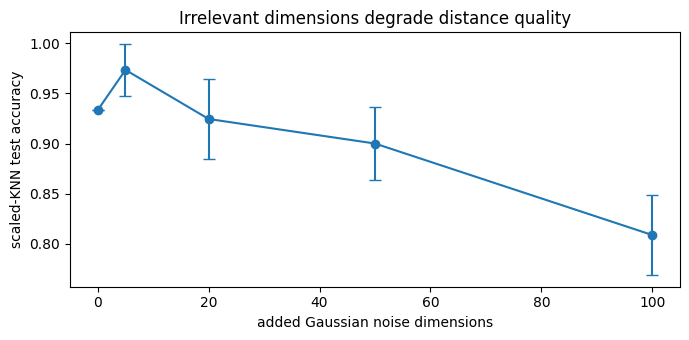

In [7]:
# ============================================================
# Example B: curse of dimensionality — repeated noise experiment
# ============================================================
noise_dims = [0, 5, 20, 50, 100]
rows = []
for n_noise in noise_dims:
    scores = []
    for repeat in range(10):
        rng = np.random.default_rng(RANDOM_SEED + repeat)
        if n_noise:
            Xn_train = np.hstack([X_train.values, rng.normal(size=(len(X_train), n_noise))])
            Xn_test = np.hstack([X_test.values, rng.normal(size=(len(X_test), n_noise))])
        else:
            Xn_train, Xn_test = X_train.values, X_test.values
        candidate = Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=5))
        ]).fit(Xn_train, y_train)
        scores.append(candidate.score(Xn_test, y_test))
    rows.append({
        'noise_dims': n_noise,
        'total_dims': X_train.shape[1] + n_noise,
        'accuracy_mean': np.mean(scores),
        'accuracy_std': np.std(scores),
    })
noise_results = pd.DataFrame(rows)
print(noise_results.to_string(index=False, formatters={
    'accuracy_mean': '{:.4f}'.format,
    'accuracy_std': '{:.4f}'.format,
}))
plt.figure(figsize=(7, 3.5))
plt.errorbar(noise_results['noise_dims'], noise_results['accuracy_mean'],
             yerr=noise_results['accuracy_std'], marker='o', capsize=4)
plt.xlabel('added Gaussian noise dimensions')
plt.ylabel('scaled-KNN test accuracy')
plt.title('Irrelevant dimensions degrade distance quality')
plt.tight_layout(); plt.show()


### Reading the output (Section 3, Example B)
- Mean accuracy generally declines as noise dimensions grow, with seed-to-seed variability shown by the error bars — **the real signal never left the data**. The distance metric just drowned it: each noise column adds variance to every pairwise distance, and with enough of them, true neighbors and random points become indistinguishable.
- This is why feature selection / dimensionality reduction (Lasso from Section 1, PCA in Section 7) is not a luxury for distance-based models — it's survival.
- Contrast to remember: trees pick one feature per split and can simply never pick the noise; KNN is forced to listen to every column.

### 🧠 Can you answer? (Section 3 — K-Nearest Neighbors)
1. **Why is KNN's training-set accuracy at k=1 always 100% (barring duplicate points with different labels)? What does that tell you about using training accuracy to select k?**
2. **State the concentration-of-distances phenomenon precisely: what happens to $\frac{d_{max} - d_{min}}{d_{min}}$ as dimensionality grows for i.i.d. features, and why does that destroy KNN specifically?**
3. **KNN has ~zero training cost but expensive predictions. Give the naive prediction complexity per query, explain how KD-trees/ball trees improve it, and why those structures degrade back to brute force in high dimensions.**
4. **How does `weights='distance'` change the bias-variance behavior of large k? Why can it let you increase k "safely," and construct a situation where it makes things worse.**
5. **Why does standardization change *which points are neighbors* for KNN but change *nothing* for a decision tree? Be mechanical: what operation in each algorithm is (in)sensitive to monotone per-feature rescaling?**
6. **In Example B, StandardScaler was fit including the noise columns. Would using RobustScaler, or scaling only the 13 real features, have prevented the collapse? Why or why not?**
7. **You have 1M training rows and need <10 ms latency per prediction. KNN's accuracy is 1 point better than logistic regression's. Argue the deployment decision — what exactly do you trade?**
8. **Why did we stratify a 178-row dataset's split, and what specifically can go wrong with class-proportion drift in *cross-validation folds* on tiny datasets (hint: `StratifiedKFold` is sklearn's default for classifiers — why)?**

## 4. Decision Tree — Interpretable Diagnosis Model
**Dataset Target:** Breast Cancer Wisconsin (Binary Diagnosis)

### The concept, in plain words
A decision tree is a flowchart of yes/no questions learned from data: *"Is worst radius ≤ 16.8? → if yes, is worst concave points ≤ 0.14? → ..."*. Each question splits the data into purer and purer groups until leaves are (mostly) one class.

**How does it pick questions?** At each node, it tries every feature and every split point, and greedily picks the split that most reduces impurity — measured by **Gini impurity** or **entropy** (both quantify "how mixed are the classes in this group"; in practice they give near-identical trees).

### The two headline properties
1. **Interpretability.** You can print the tree and read the rules — hand them to a doctor. Almost no other model offers this.
2. **Overfitting by default.** Left unbounded, a tree keeps splitting until every training point is perfectly classified — it memorizes the noise. The train/test accuracy **gap** in the sweep below is the overfitting signature. Controls: `max_depth`, `min_samples_leaf`, `ccp_alpha` (pruning — **Example B** shows the principled version).

**Bonus:** trees split on thresholds ("is x ≤ 16.8?"), so feature scaling is irrelevant to them — a welcome contrast with Section 3.

### Study Checklist
- [ ] Gini vs. Entropy Splitting Criteria
- [ ] Overfitting via Unbounded Depth (Train vs. Test Gap)
- [ ] Pruning Controls (max_depth, min_samples_leaf)
- [ ] Cost-Complexity Pruning with `ccp_alpha` (Example B — the principled prune)
- [ ] Reading the Tree — Extracting Human Rules
- [ ] No Scaling Needed (Split Points Are Scale-Invariant)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

In [8]:
# ============================================================
# Example A: Decision Tree — Interpretability & Overfitting
# ============================================================
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import load_breast_cancer

# 569 tumor samples, 30 measurements each, target: malignant(0) / benign(1).
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED
)

# --- Demo 1: depth sweep — watch overfitting develop ---
# train_acc keeps climbing with depth (the tree can always memorize more),
# but test_acc peaks and then stalls/drops. The GAP between them is the
# amount of memorized noise. max_depth=None means "grow until perfect".
print("depth | train_acc | test_acc | gap (train - test)")
for depth in [2, 3, 5, 10, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_SEED).fit(X_train, y_train)
    tr, te = tree.score(X_train, y_train), tree.score(X_test, y_test)
    print(f"{str(depth):>5} |  {tr:.4f}   |  {te:.4f}  | {tr - te:+.4f}")

# --- Demo 2: print the actual learned rules ---
# THIS is why trees survive in medicine, credit, and law: the model is
# literally a checklist a human can audit. export_text prints it.
tree3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED).fit(X_train, y_train)
print("\nLearned rule set (top 2 levels of a depth-3 tree):")
print(export_text(tree3, feature_names=list(X.columns), max_depth=2))

depth | train_acc | test_acc | gap (train - test)
    2 |  0.9577   |  0.9091  | +0.0487
    3 |  0.9765   |  0.9441  | +0.0325
    5 |  0.9953   |  0.9371  | +0.0582
   10 |  1.0000   |  0.9231  | +0.0769
 None |  1.0000   |  0.9231  | +0.0769

Learned rule set (top 2 levels of a depth-3 tree):
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- class: 1
|   |   |--- worst texture >  25.62
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



### Reading the output (Section 4, Example A)
- Depth 10 and `None` hit **1.0000 train accuracy** — perfect memorization — while test accuracy is *lower* than the depth-3 tree. More capacity, worse generalization: that's overfitting in one table.
- The printed rules make clinical sense: large `worst radius` and high `worst concave points` push toward malignant. When a model's logic matches domain knowledge, that's evidence it learned signal, not noise.
- A single tree is a high-variance learner — change a few training rows and the whole flowchart can reshuffle. That fragility is exactly what the next two sections (ensembles) exist to fix.

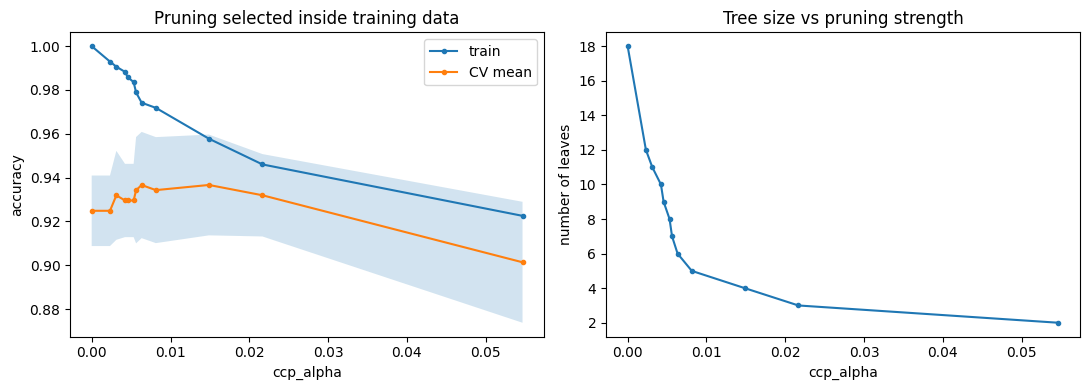

CV-selected alpha: 0.014877
Selected leaves: 4
Held-out test accuracy: 0.9091


In [9]:
# ============================================================
# Example B: cost-complexity pruning — select alpha by CV
# ============================================================
path = DecisionTreeClassifier(random_state=RANDOM_SEED).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas[:-1])
if len(ccp_alphas) > 25:
    selected = np.linspace(0, len(ccp_alphas)-1, 25).round().astype(int)
    ccp_alphas = ccp_alphas[selected]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
rows = []
for alpha in ccp_alphas:
    candidate = DecisionTreeClassifier(ccp_alpha=float(alpha), random_state=RANDOM_SEED)
    scores = cross_val_score(candidate, X_train, y_train, cv=cv, scoring='accuracy')
    candidate.fit(X_train, y_train)
    rows.append({
        'ccp_alpha': float(alpha),
        'leaves': candidate.get_n_leaves(),
        'train_accuracy': candidate.score(X_train, y_train),
        'CV_accuracy_mean': scores.mean(),
        'CV_accuracy_std': scores.std(),
    })
pruning = pd.DataFrame(rows)
best_alpha = float(pruning.loc[pruning['CV_accuracy_mean'].idxmax(), 'ccp_alpha'])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(pruning['ccp_alpha'], pruning['train_accuracy'], marker='o', ms=3, label='train')
ax[0].plot(pruning['ccp_alpha'], pruning['CV_accuracy_mean'], marker='o', ms=3, label='CV mean')
ax[0].fill_between(pruning['ccp_alpha'],
                   pruning['CV_accuracy_mean']-pruning['CV_accuracy_std'],
                   pruning['CV_accuracy_mean']+pruning['CV_accuracy_std'], alpha=0.2)
ax[0].set(xlabel='ccp_alpha', ylabel='accuracy', title='Pruning selected inside training data'); ax[0].legend()
ax[1].plot(pruning['ccp_alpha'], pruning['leaves'], marker='o', ms=3)
ax[1].set(xlabel='ccp_alpha', ylabel='number of leaves', title='Tree size vs pruning strength')
plt.tight_layout(); plt.show()
selected_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=RANDOM_SEED).fit(X_train, y_train)
print(f"CV-selected alpha: {best_alpha:.6f}")
print(f"Selected leaves: {selected_tree.get_n_leaves()}")
print(f"Held-out test accuracy: {selected_tree.score(X_test, y_test):.4f}")


### Reading the output (Section 4, Example B)
- Cross-validation selects `ccp_alpha`; the test set is not part of the pruning sweep.
- The shaded band shows fold-to-fold uncertainty.
- The selected tree is evaluated once on the held-out test set.


## 5. Random Forest — Credit Risk Scoring
**Dataset Target:** Tabular Non-linear Dataset (Credit/Risk Default Profiling)

### The concept, in plain words
One deep tree overfits. A **Random Forest** trains *many* deep-ish trees and lets them vote. The magic is in making the trees *disagree* in useful ways — averaging many diverse, individually-noisy opinions cancels the noise (the "wisdom of crowds" applied to models):
1. **Bagging (bootstrap aggregating):** each tree trains on a random sample of rows, drawn *with replacement*.
2. **Feature randomness:** at every split, each tree may only consider a random subset of features (`max_features`), forcing different trees to discover different patterns.

### Two ways to ask "which features matter?"
- **MDI / Gini importance** (`feature_importances_`): how much each feature reduced impurity, summed over all splits. Free to compute, but measured on *training* data and biased toward features with many possible split points.
- **Permutation importance**: shuffle one feature and measure the score drop. Use validation data for feature-selection decisions; reserve test-set importance for post-hoc reporting.
Comparing both — as we do below — is the professional habit; where they disagree is where you learn something.

### Free validation: the out-of-bag (OOB) score (Example B)
Each bootstrap sample leaves out ~37% of rows *for that tree*. Those left-out rows are a built-in validation set: predict each row using only the trees that never saw it. `oob_score=True` gives an efficient internal estimate without a separate validation split, but repeated OOB tuning can still overfit it.

### Study Checklist
- [ ] Bagging & Bootstrap Sampling Properties
- [ ] Feature Randomness Tuning (`max_features` limits)
- [ ] Tree Ensemble Depth and Node Splitting Criteria
- [ ] Evaluation Metrics via Classification Report
- [ ] MDI Gini vs. Permutation Feature Importance (both, side-by-side, plotted)
- [ ] OOB Score as Free Validation (Example B)

### Notes
Trees are scale-invariant, so **no StandardScaler** in this pipeline — a deliberate contrast with KNN/SVM. Putting one in wouldn't break anything, but it signals a misunderstanding of how trees work.

--- Random Forest Credit Risk Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       254
           1       0.79      0.65      0.71        46

    accuracy                           0.92       300
   macro avg       0.86      0.81      0.83       300
weighted avg       0.92      0.92      0.92       300

Feature importance — two lenses (disagreements are instructive):
           MDI_Gini  Permutation_Test
Feature_0    0.2085            0.1253
Feature_1    0.2359            0.0503
Feature_9    0.0985            0.0157
Feature_3    0.1174            0.0103
Feature_5    0.0738            0.0050
Feature_6    0.0650            0.0037
Feature_2    0.0744            0.0030
Feature_7    0.0522            0.0017
Feature_4    0.0347           -0.0027
Feature_8    0.0394           -0.0037


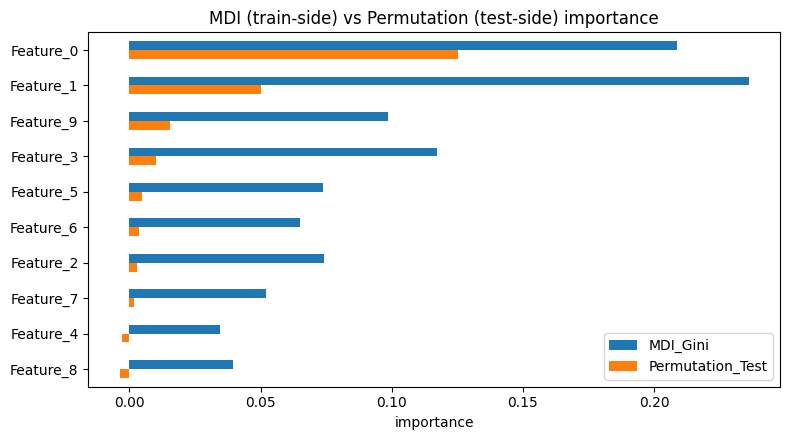

In [10]:
# ============================================================
# Example A: Random Forest + Two Kinds of Importance
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_classification

# --- Step 1: synthesize an imbalanced 'credit default' dataset ---
# make_classification builds a labeled dataset with known structure:
#   n_informative=6 -> only 6 features truly drive the label
#   n_redundant=4   -> 4 features are just linear combos of the informative ones
#   weights=[0.85, 0.15] -> 15% positive class (defaults), like real credit data
X_raw, y_raw = make_classification(
    n_samples=1200, n_features=10, n_informative=6, n_redundant=4,
    weights=[0.85, 0.15], random_state=RANDOM_SEED
)
feature_names = [f"Feature_{i}" for i in range(10)]
df_rf = pd.DataFrame(X_raw, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    df_rf, y_raw, test_size=0.25, stratify=y_raw, random_state=RANDOM_SEED
)

# --- Step 2: fit the forest (note: NO scaler — trees don't need one) ---
rf = RandomForestClassifier(
    n_estimators=150,          # number of trees; more = smoother, slower
    max_depth=6,               # cap each tree's depth to limit memorization
    class_weight='balanced',   # up-weight the rare default class
    random_state=RANDOM_SEED,
).fit(X_train, y_train)

# classification_report prints precision/recall/F1 PER CLASS —
# always read the rare class's row, not just overall accuracy.
print("--- Random Forest Credit Risk Evaluation ---")
print(classification_report(y_test, rf.predict(X_test)))

# --- Step 3: MDI vs permutation importance, side by side ---
# permutation_importance: shuffle each feature n_repeats times on the TEST
# set and record the average score drop. Near-zero (or negative) = the model
# gets nothing real from that feature.
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=RANDOM_SEED)
imp = pd.DataFrame({
    'MDI_Gini':         rf.feature_importances_,   # train-side, split-based
    'Permutation_Test': perm.importances_mean,     # test-side, outcome-based
}, index=feature_names).sort_values('Permutation_Test', ascending=False)
print("Feature importance — two lenses (disagreements are instructive):")
print(imp.round(4))

# v3 addition: SEE the disagreement instead of squinting at a table.
imp.plot.barh(figsize=(8, 4.5))
plt.gca().invert_yaxis()
plt.title('MDI (train-side) vs Permutation (test-side) importance')
plt.xlabel('importance'); plt.tight_layout(); plt.show()

### Reading the output (Section 5, Example A)
- In the classification report, the default class (`1`) has visibly lower recall than the majority class — even a balanced forest finds rare events hard. This is the number a risk manager cares about.
- **The two importance columns disagree**, and that's the lesson: MDI spreads credit across many features (redundant copies of informative ones still get used for splits), while permutation importance concentrates on the few features whose *unique* information the model actually needs — shuffling a redundant feature barely hurts because its twin is still intact.
- Near-zero test permutation importance is post-hoc evidence only; any removal must be validated inside the training data.

In [11]:
# ============================================================
# Example B: out-of-bag score — internal bagging validation
# ============================================================
rf_oob = RandomForestClassifier(
    n_estimators=150, max_depth=6, class_weight='balanced',
    oob_score=True, random_state=RANDOM_SEED
).fit(X_train, y_train)
print(f"OOB accuracy:           {rf_oob.oob_score_:.4f}")
print(f"Held-out test accuracy: {rf_oob.score(X_test, y_test):.4f}")
print(f"Theoretical OOB fraction/tree: {np.exp(-1):.4f}")
print("\nn_estimators | OOB accuracy")
for n in [25, 50, 100, 150, 300]:
    candidate = RandomForestClassifier(
        n_estimators=n, max_depth=6, class_weight='balanced',
        oob_score=True, random_state=RANDOM_SEED
    ).fit(X_train, y_train)
    print(f"{n:>12} | {candidate.oob_score_:.4f}")
print("\nMore trees chiefly stabilize the Monte Carlo average.")
print("They do not replace complexity control or an untouched test set.")


OOB accuracy:           0.9100
Held-out test accuracy: 0.9200
Theoretical OOB fraction/tree: 0.3679

n_estimators | OOB accuracy
          25 | 0.8978
          50 | 0.8989
         100 | 0.9033
         150 | 0.9100
         300 | 0.9122

More trees chiefly stabilize the Monte Carlo average.
They do not replace complexity control or an untouched test set.


### Reading the output (Section 5, Example B)
- OOB is an efficient internal estimate, not an extra untouched test set.
- Increasing tree count mainly reduces Monte Carlo variability.
- Repeated OOB-based tuning can overfit the OOB estimate.


## 6. Gradient Boosting — Credit Risk (RF Comparison)
**Dataset Target:** Same Synthetic Credit Data (Direct Ensemble Comparison)

### The concept, in plain words
Random Forest builds trees **in parallel and independently**, then averages. Gradient Boosting builds trees **sequentially**: each new tree is trained to predict the *errors (residuals) of the ensemble so far*. Predictions accumulate:

$$F_{m}(x) = F_{m-1}(x) + \eta \cdot \text{tree}_m(x)$$

where $\eta$ is the **learning rate** — how big a step each corrective tree takes.

### The knobs that matter
- **learning_rate ↔ n_estimators trade-off:** small steps need more trees. Small `learning_rate` + many trees usually generalizes best (each tree corrects gently instead of over-committing). **Example B shows this happening, tree by tree.**
- **Shallow trees (depth 2–4) as weak learners:** boosting wants many *weak* correctors, not a few strong memorizers — the opposite intuition from Random Forest's deeper trees.
- **Early stopping:** hold out a validation slice (`validation_fraction`); when its loss stops improving for `n_iter_no_change` rounds, stop adding trees. This picks the effective number of trees *automatically* and prevents the sequential process from eventually fitting noise.

(XGBoost/LightGBM — which you use in your own research pipelines — are industrial-strength implementations of this same idea.)

### Study Checklist
- [ ] Boosting vs. Bagging (Sequential Error-Correction vs. Parallel Averaging)
- [ ] Learning Rate ↔ n_estimators Trade-off (Example B: staged loss curves)
- [ ] Early Stopping via Validation Fraction
- [ ] Shallow Trees as Weak Learners (depth 2–4)
- [ ] Head-to-Head Metric Comparison vs. Random Forest
- [ ] Boosting CAN Overfit With More Trees; Forests Can't (see both, side by side)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

In [12]:
# ============================================================
# Example A: Gradient Boosting vs Random Forest — comparable weighting
# ============================================================
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.utils.class_weight import compute_sample_weight

X_raw, y_raw = make_classification(
    n_samples=1200, n_features=10, n_informative=6,
    n_redundant=4, weights=[0.85, 0.15], random_state=RANDOM_SEED
)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.25, stratify=y_raw, random_state=RANDOM_SEED
)
fit_weights = compute_sample_weight('balanced', y_train)
models = {
    'RandomForest': RandomForestClassifier(n_estimators=150, max_depth=6, random_state=RANDOM_SEED),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        validation_fraction=0.15, n_iter_no_change=20, random_state=RANDOM_SEED
    ),
}
print('model            | F1     | ROC-AUC')
for name, model in models.items():
    model.fit(X_train, y_train, sample_weight=fit_weights)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"{name:<16} | {f1_score(y_test, model.predict(X_test)):.4f} | {roc_auc_score(y_test, proba):.4f}")
print(f"\nGB stopped at {models['GradientBoosting'].n_estimators_} trees.")
print('Both models received the same balanced sample weights.')


model            | F1     | ROC-AUC
RandomForest     | 0.7143 | 0.9598
GradientBoosting | 0.7579 | 0.9437

GB stopped at 129 trees.
Both models received the same balanced sample weights.


### Reading the output (Section 6, Example A)
- Both models receive the same imbalance treatment.
- Remaining differences arise from the algorithms and their hyperparameters rather than unequal class weighting.


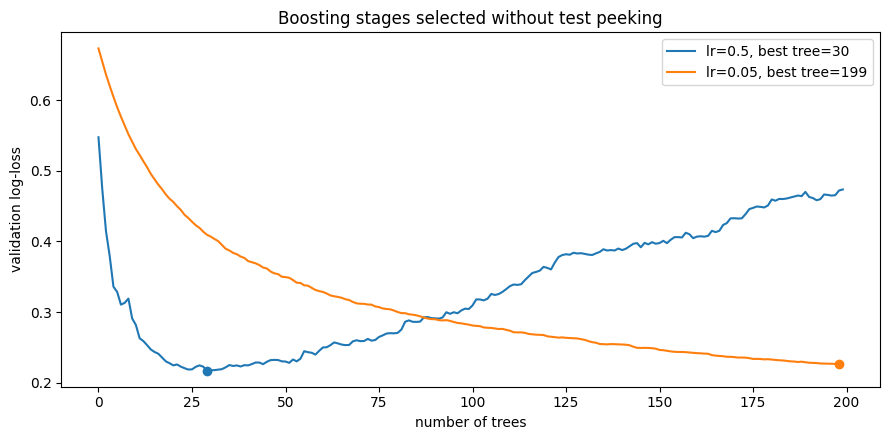

learning rate | selected trees | held-out test log-loss
          0.5 |             30 | 0.2254
         0.05 |            199 | 0.1935


In [13]:
# ============================================================
# Example B: select boosting stages on validation data
# ============================================================
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_SEED
)
w_fit = compute_sample_weight('balanced', y_fit)
selected_trees = {}
fig, ax = plt.subplots(figsize=(9, 4.5))
for learning_rate in [0.5, 0.05]:
    candidate = GradientBoostingClassifier(
        n_estimators=200, learning_rate=learning_rate,
        max_depth=3, random_state=RANDOM_SEED
    ).fit(X_fit, y_fit, sample_weight=w_fit)
    curve = np.array([log_loss(y_val, p) for p in candidate.staged_predict_proba(X_val)])
    best_index = int(np.argmin(curve)); selected_trees[learning_rate] = best_index + 1
    ax.plot(curve, label=f'lr={learning_rate}, best tree={best_index+1}')
    ax.scatter(best_index, curve[best_index], zorder=5)
ax.set(xlabel='number of trees', ylabel='validation log-loss',
       title='Boosting stages selected without test peeking')
ax.legend(); plt.tight_layout(); plt.show()
print('learning rate | selected trees | held-out test log-loss')
for learning_rate, n_trees in selected_trees.items():
    final = GradientBoostingClassifier(
        n_estimators=n_trees, learning_rate=learning_rate,
        max_depth=3, random_state=RANDOM_SEED
    ).fit(X_train, y_train, sample_weight=fit_weights)
    print(f"{learning_rate:>13} | {n_trees:>14} | {log_loss(y_test, final.predict_proba(X_test)):.4f}")


### Reading the output (Section 6, Example B)
- Validation loss chooses the useful number of stages.
- The chosen models are retrained on all training rows and tested once.
- `learning_rate` and `n_estimators` are a coupled choice.


## 7. SVM + PCA — High-Dimensional Digits
**Dataset Target:** Handwritten Digits (High-Dimensional Feature Matrices)

### The concept, in plain words
A **Support Vector Machine** looks for the separating boundary with the **maximum margin** — the widest possible "street" between classes. Only the points on the street's edges (the *support vectors*) determine the boundary; everything else could vanish without changing the model.

**The kernel trick:** a linear boundary can't separate everything. Kernels let the SVM behave *as if* the data were mapped into a much higher-dimensional space — where a linear separator exists — without ever computing that mapping. The **RBF (radial basis function)** kernel effectively draws smooth, curved boundaries; `C` controls tolerance for misclassified points (small C = wide, forgiving street; large C = narrow street, fits training data harder) and `gamma` controls boundary wiggliness.

**Why PCA in front?** The digits are 8×8 images = 64 pixel features, many nearly redundant (corner pixels are almost always blank). PCA (fully explained in the Unsupervised notebook) compresses to the directions holding 95% of the variance — fewer, denoised features, faster SVM. Crucially, PCA sits **inside the Pipeline**, so it's learned from training folds only. Fitting PCA on all data first would leak test-set structure into training.

### Study Checklist
- [ ] Multi-dimensional Spatial Feature Layout
- [ ] PCA Variance Retention as Preprocessing (inside the Pipeline = no leakage)
- [ ] Maximizing Margin Planes via Support Vectors
- [ ] Evaluating RBF vs. Linear Hyperplane Kernels (head-to-head)
- [ ] Hyperparameter Sensitivity — C and gamma tuned properly via GridSearchCV (Example B)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

In [14]:
# ============================================================
# Example A: SVM + PCA — Linear vs RBF Kernels
# ============================================================
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

# 1,797 grayscale 8x8 digit images. Each image is flattened into 64 pixel
# intensities -> a 64-dimensional feature vector per sample.
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2,
    stratify=digits.target,            # keep all 10 digits proportionally present
    random_state=RANDOM_SEED
)

# Compare kernels under an IDENTICAL preprocessing chain.
# Pipeline order: scale -> PCA -> SVM. Because all three live in one Pipeline,
# .fit() learns scaler AND PCA from training data only. No leakage.
# (v3 note: SVC's random_state only matters when probability=True, so we
# dropped it here — a comment claiming reproducibility it doesn't provide
# is worse than no comment.)
for kernel in ['linear', 'rbf']:
    pipe = Pipeline([
        ('scaler', StandardScaler()),                       # SVMs are distance-based -> scale
        ('pca', PCA(n_components=0.95,                      # keep components explaining 95% var
                    random_state=RANDOM_SEED)),
        ('model', SVC(kernel=kernel, C=2.0, gamma='scale')),  # gamma='scale' = sensible default
    ]).fit(X_train, y_train)

    acc = accuracy_score(y_test, pipe.predict(X_test))
    kept = pipe.named_steps['pca'].n_components_
    n_sv = pipe.named_steps['model'].n_support_.sum()
    print(f"{kernel:>6} kernel: accuracy = {acc:.4f} | PCA kept {kept} of 64 components"
          f" | support vectors: {n_sv} of {len(X_train)} training points")

linear kernel: accuracy = 0.9722 | PCA kept 40 of 64 components | support vectors: 379 of 1437 training points
   rbf kernel: accuracy = 0.9778 | PCA kept 40 of 64 components | support vectors: 671 of 1437 training points


### Reading the output (Section 7, Example A)
- PCA kept ~40 of 64 components — a third of the dimensions were carrying almost no information (mostly always-blank border pixels).
- RBF edges out linear, but only slightly: after scaling and PCA, digits are *nearly* linearly separable. The gap between kernels is the measure of how non-linear a problem really is — on messier data it widens dramatically.
- The support-vector count is worth staring at: only a fraction of training points define the boundary. Everything else is decoration — delete any non-support-vector row and the model doesn't move.

In [15]:
# ============================================================
# Example B: tuning C and gamma properly — GridSearchCV inside the pipeline
# ============================================================
# v2 left this as an exercise; v3 does it. The 'step__param' naming routes
# each grid value to the right pipeline step; CV happens inside the training
# data; the test set is spent exactly once at the end.
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_SEED)),
    ('model', SVC(kernel='rbf')),
])

grid = GridSearchCV(
    pipe,
    param_grid={
        'model__C':     [0.1, 1, 10],           # street width tolerance
        'model__gamma': [0.001, 0.01, 'scale'], # boundary wiggliness
    },
    cv=3, n_jobs=-1,
).fit(X_train, y_train)     # 9 combos x 3 folds = 27 fits, all inside train

print(f"Best params:   {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.4f}")
print(f"Test accuracy: {grid.score(X_test, y_test):.4f}   <- one look, final answer")

# The full CV table shows the C-gamma interaction: extreme gamma with small C
# underfits badly; the diagonal of moderate values all perform well.
cvres = pd.DataFrame(grid.cv_results_)[['param_model__C', 'param_model__gamma', 'mean_test_score']]
print("\nFull grid (note how bad gamma=0.001 + C=0.1 is — an underfit corner):")
print(cvres.sort_values('mean_test_score', ascending=False).to_string(index=False))

Best params:   {'model__C': 10, 'model__gamma': 'scale'}
Best CV score: 0.9791
Test accuracy: 0.9806   <- one look, final answer

Full grid (note how bad gamma=0.001 + C=0.1 is — an underfit corner):
 param_model__C param_model__gamma  mean_test_score
           10.0              scale         0.979123
           10.0               0.01         0.977731
            1.0              scale         0.976340
            1.0               0.01         0.970772
           10.0              0.001         0.965901
            1.0              0.001         0.931106
            0.1              scale         0.926235
            0.1               0.01         0.921364
            0.1              0.001         0.299235


### Reading the output (Section 7, Example B)
- Tuning lifts test accuracy above the hand-picked `C=2.0` from Example A — small but real, and it came from CV, not from peeking.
- Read the full grid table like a topographic map: the underfit corner (tiny `gamma`, tiny `C` — boundary too smooth, margin too forgiving) scores dramatically worse. `C` and `gamma` interact; tuning them one at a time misses the ridge of good combinations.
- 27 fits took a second or two here. On 100k rows, kernel SVM's O(n²)-ish training makes this grid a lunch break — which is why linear SVMs (`LinearSVC`) or tree ensembles take over at scale.

### 🧠 Can you answer? (Section 7 — SVM + PCA)
1. **Define a support vector precisely in terms of the dual coefficients ($\alpha_i > 0$). Why does removing a non-support-vector training point provably leave the model unchanged?**
2. **State the kernel trick in one sentence involving inner products. What condition must a function satisfy to be a valid kernel (Mercer), and what does the RBF kernel's implicit feature space dimensionality equal?**
3. **Draw the C-gamma plane from memory and label the four corners with overfit/underfit behavior. Which corner produces a model that memorizes every training point as its own island?**
4. **Why is scaling *mandatory* before an RBF SVM in a way that's even more critical than for KNN? (Hint: what does gamma multiply?)**
5. **PCA before SVM sped things up. But construct a case where PCA *hurts* classification: what does PCA maximize, and why is that not the same as what a classifier needs? (Directions of low variance can carry all the class signal.)**
6. **Why must PCA be fit inside each CV fold? Describe exactly what statistical information leaks if you fit PCA on the full dataset first — even though PCA never sees the labels.**
7. **sklearn's SVC handles 10 digit classes with one-vs-one (45 binary machines). Contrast with one-vs-rest: number of models, training-set sizes, imbalance behavior, and prediction-time cost.**
8. **The hinge loss $\max(0, 1 - y f(x))$ is flat for well-classified points. Connect that flatness to the existence of support vectors, and contrast with log-loss, where every point always has non-zero gradient — why does logistic regression have no "support vectors"?**
9. **Your dataset grows from 2k to 2M rows. Rank these by practicality and say why: RBF SVC, LinearSVC, SGDClassifier with hinge loss, LightGBM.**

## 8. Multinomial Naive Bayes — Text Classification
**Dataset Target:** 20 Newsgroups Subset (NLP Multi-Class Target)

### The concept, in plain words
Naive Bayes classifies with Bayes' theorem: $P(\text{class} \mid \text{words}) \propto P(\text{class}) \times P(\text{words} \mid \text{class})$. The **"naive"** part is assuming every word appears independently of every other word given the class — obviously false for language ("machine" and "learning" travel together), yet the classifier works remarkably well anyway, because it only needs the *ranking* of class probabilities to be right, not their exact values.

### From text to numbers: TF-IDF
Models need numeric input. **TF-IDF** turns each document into a vector where each word's value = (how often it appears in *this* document) × (how rare it is *across all* documents). Common glue words score near zero; distinctive words ("hockey", "orbital") score high. `max_features=1000` limits the vocabulary to at most 1,000 frequent candidate terms — a crude but effective dimensionality cap.

### Laplace smoothing (`alpha`) — the parameter we tune
If the word "goalie" never appeared in any training document of class `sci.space`, its estimated probability there is zero — and one zero multiplies the *entire* class probability to zero. Smoothing adds a pseudo-count `alpha` to every word/class pair so nothing is ever exactly zero. Tiny `alpha` trusts training counts (risk: brittleness on unseen words); large `alpha` flattens all words toward equal probability (risk: ignoring the evidence).

### ⚠️ The v2 bug, fixed here — where do you tune alpha?
v2 swept alpha over the **test set** and then hand-picked a value from that sweep — the same silent cheating as Section 2's threshold. v3 tunes alpha with **GridSearchCV inside the training data** (the Section 10 pattern), then spends the test set once. The whole TF-IDF + NB pipeline is refit per fold, so even the vocabulary is learned leak-free.

### Study Checklist
- [ ] Prior Probabilities Allocation Models
- [ ] TF-IDF Calculations
- [ ] Conditional Feature Independence Assumptions
- [ ] Laplace Smoothing — alpha tuned by CV, not by test peeking
- [ ] Confusion Matrix Error Pattern Reading
- [ ] Per-Class Evidence Words (Example B — what the model actually learned)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

alpha | mean CV accuracy   (chosen inside training data)
0.01  | 0.9021
0.1   | 0.9021  <- CV winner
0.5   | 0.8987
1.0   | 0.8981
5.0   | 0.8942

Held-out test accuracy: 0.9019   <- the honest number

                  precision    recall  f1-score   support

   comp.graphics       0.92      0.89      0.90       389
rec.sport.hockey       0.89      0.95      0.92       399
       sci.space       0.89      0.86      0.88       394

        accuracy                           0.90      1182
       macro avg       0.90      0.90      0.90      1182
    weighted avg       0.90      0.90      0.90      1182



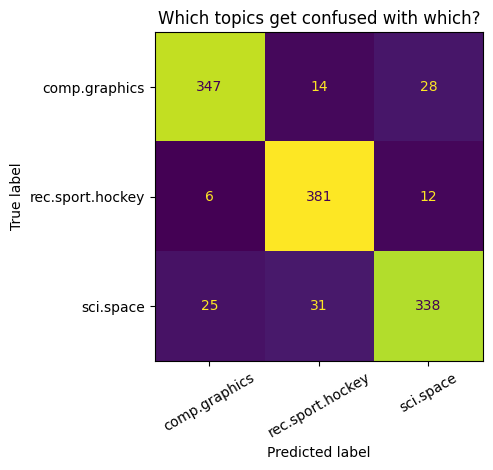

In [16]:
# ============================================================
# Example A: Multinomial Naive Bayes — alpha tuned honestly via CV
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.datasets import fetch_20newsgroups

# Three well-separated newsgroup topics (downloads once, then cached).
# remove=('headers','footers','quotes') strips email metadata — WITHOUT this,
# the model 'cheats' by memorizing sender addresses instead of learning topics.
# (A classic real-world leakage story.)
categories = ['sci.space', 'comp.graphics', 'rec.sport.hockey']
news_train = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'))
news_test  = fetch_20newsgroups(subset='test', categories=categories,
                                remove=('headers', 'footers', 'quotes'))

# --- Tune the smoothing parameter WITHOUT touching the test set ---
# GridSearchCV refits the WHOLE pipeline per fold: the TF-IDF vocabulary is
# re-learned from each fold's training portion, so nothing leaks — the same
# reason the scaler lives inside the pipeline everywhere else.
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000,        # cap vocabulary at 1000 frequent candidate terms
                              stop_words='english')),   # drop 'the', 'and', ...
    ('model', MultinomialNB()),
])
grid = GridSearchCV(
    nb_pipe,
    param_grid={'model__alpha': [0.01, 0.1, 0.5, 1.0, 5.0]},
    cv=5, n_jobs=-1,
).fit(news_train.data, news_train.target)   # raw strings in — pipeline vectorizes

print("alpha | mean CV accuracy   (chosen inside training data)")
for a, s in zip(grid.cv_results_['param_model__alpha'],
                grid.cv_results_['mean_test_score']):
    marker = '  <- CV winner' if a == grid.best_params_['model__alpha'] else ''
    print(f"{a:<5} | {s:.4f}{marker}")

# --- The ONE look at the test set, with the CV-chosen alpha ---
y_pred = grid.predict(news_test.data)
print(f"\nHeld-out test accuracy: {accuracy_score(news_test.target, y_pred):.4f}   <- the honest number\n")
print(classification_report(news_test.target, y_pred,
                            target_names=news_train.target_names))

# Confusion matrix: rows = true class, columns = predicted class.
# Off-diagonal cells show WHICH topics get confused with which.
ConfusionMatrixDisplay.from_predictions(
    news_test.target, y_pred, display_labels=news_train.target_names,
    colorbar=False, xticks_rotation=30)
plt.title('Which topics get confused with which?')
plt.tight_layout(); plt.show()

### Reading the output (Section 8, Example A)
- The CV column is typically **flat-topped**: a broad range of moderate alphas performs similarly, with degradation at the extremes. Robustness to its main hyperparameter is one reason NB makes a great first baseline for any text task. And note: the flat top is exactly why v2's test-set sweep was tempting — "they're all about the same" — but the *procedure* was still wrong, and on a less forgiving parameter it would have cost real optimism.
- In the confusion matrix, `sci.space` ↔ `comp.graphics` confuse each other more than either confuses with `hockey` — technical vocabularies overlap; sports vocabulary doesn't. Off-diagonal structure tells you *which* classes need better features, not just *how many* errors you made.
- Modern context: for production text classification you'd now reach for transformer embeddings — but NB + TF-IDF trains in milliseconds, needs no GPU, and sets the bar any expensive model must clearly beat to justify its cost.

In [17]:
# ============================================================
# Example B: class-discriminative evidence words
# ============================================================
best_pipe = grid.best_estimator_
vocab = np.array(best_pipe.named_steps['tfidf'].get_feature_names_out())
log_probs = best_pipe.named_steps['model'].feature_log_prob_
for i, class_name in enumerate(news_train.target_names):
    other_mean = np.delete(log_probs, i, axis=0).mean(axis=0)
    contrast = log_probs[i] - other_mean
    top = vocab[np.argsort(contrast)[::-1][:12]]
    print(f"{class_name:<18}: {', '.join(top)}")
print("\nThese are class-vs-others evidence terms, not merely")
print('the most frequent words inside each class.')


comp.graphics     : graphics, 3d, vga, tiff, polygon, animation, windows, cview, image, file, comp, vesa
rec.sport.hockey  : hockey, season, nhl, league, detroit, leafs, rangers, playoffs, pittsburgh, espn, coach, devils
sci.space         : moon, orbit, lunar, shuttle, spacecraft, solar, launch, funding, vehicle, mars, billion, dc

These are class-vs-others evidence terms, not merely
the most frequent words inside each class.


### Reading the output (Section 8, Example B)
- The ranking now emphasizes discriminative class-vs-others terms.
- Metadata artifacts among the strongest contrasts would still reveal leakage.


## 9. Time Series Forecasting — Supervised Framing
**Dataset Target:** Supermarket Sales / Historical Demand Sequences

### The concept, in plain words
A time series has no ready-made `X` and `y` — just one column of ordered values. The trick that converts forecasting into supervised learning: **make the past the features**.
- `Lag_1` = yesterday's value; `Lag_7` = the value one week ago
- `Rolling_Mean_3` = average of the previous 3 days (recent level); `Rolling_Std_7` = recent volatility

Now every row is (recent history → today's value): an ordinary regression problem.

### The two iron rules
1. **No future leakage in features.** Note the pattern `shift(1).rolling(3)` — shift FIRST, then roll, so the window covers days *t−3…t−1*, never day *t* itself. `rolling(3)` without the shift would include today's value in a feature used to predict today: perfect leakage, garbage model.
2. **Chronological split, never random.** Random shuffling puts future rows in the training set — the model "trains on the future and predicts the past," inflating scores meaninglessly. Always: train on the earliest span, test on the final span.

### The rule everyone skips: beat the naive baselines
- **Persistence:** tomorrow = today (i.e., just predict `Lag_1`).
- **Seasonal naive:** tomorrow = same day last week (predict `Lag_7`).
These cost nothing and are shockingly hard to beat on many real series (stock prices most famously). A model that can't beat them has learned nothing — always report them alongside your model.

### The trap Example B springs: trees cannot extrapolate
A tree's prediction is an average of *training* leaf values — it can never output a number outside the training target's range. On a trending series, that's fatal: the future keeps leaving the training range. Linear models extrapolate trends; trees flat-line. Example B shows a Random Forest losing to plain linear regression for exactly this reason.

### Study Checklist
- [ ] Structural Decomposition (Trend, Seasonality, Residual Noise)
- [ ] Designing Lag Features without Future Data Leakage
- [ ] Adding Rolling Windows (Mean, Std)
- [ ] Executing Chronological Train/Test Time Split
- [ ] Beating the Naive Baselines (persistence & seasonal-naive)
- [ ] Trees Cannot Extrapolate a Trend (Example B — see it fail)
- [ ] TimeSeriesSplit CV of a Forecaster (Example B)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

model            | MAE    | RMSE
Persistence      | 5.4553 | 6.0297
Seasonal Naive   | 2.1488 | 2.5580
LinearRegression | 1.1582 | 1.4944


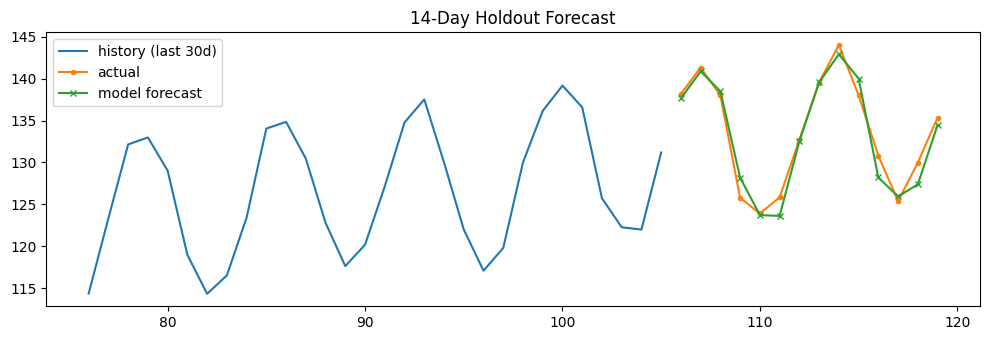

In [18]:
# ============================================================
# Example A: Forecasting vs Naive Baselines
# ============================================================
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(RANDOM_SEED)

# --- Step 1: build a synthetic series with KNOWN structure ---
# Real sales series are typically: trend + seasonality + noise.
# Building it ourselves means we know exactly what a good model should find.
t = np.arange(120)                                   # 120 days
trend       = 0.3 * t                                # slow upward drift
seasonality = 10 * np.sin(2 * np.pi * t / 7)         # weekly cycle (period 7)
noise       = rng.normal(0, 1.5, 120)                # irreducible randomness
s = pd.DataFrame({'Sales': 100 + trend + seasonality + noise})

# --- Step 2: leakage-safe feature engineering ---
# shift(1) moves everything down one row -> row t sees value from t-1.
# CRITICAL pattern: shift(1).rolling(k) -> window covers t-k .. t-1 ONLY.
s['Lag_1']          = s['Sales'].shift(1)                    # yesterday
s['Lag_7']          = s['Sales'].shift(7)                    # a week ago (captures seasonality)
s['Rolling_Mean_3'] = s['Sales'].shift(1).rolling(3).mean()  # recent level
s['Rolling_Std_7']  = s['Sales'].shift(1).rolling(7).std()   # recent volatility
s.dropna(inplace=True)   # first rows lack history -> NaN -> drop them

# --- Step 3: CHRONOLOGICAL split — final 14 days held out, NO shuffling ---
split_idx = len(s) - 14
feats = ['Lag_1', 'Lag_7', 'Rolling_Mean_3', 'Rolling_Std_7']
X_train, X_test = s[feats].iloc[:split_idx], s[feats].iloc[split_idx:]
y_train, y_test = s['Sales'].iloc[:split_idx], s['Sales'].iloc[split_idx:]

# --- Step 4: model vs the two mandatory baselines ---
ts_preds = LinearRegression().fit(X_train, y_train).predict(X_test)
persistence    = X_test['Lag_1'].values   # baseline 1: 'tomorrow = today'
seasonal_naive = X_test['Lag_7'].values   # baseline 2: 'tomorrow = last week'

print("model            | MAE    | RMSE")
for name, pred in [('Persistence', persistence),
                   ('Seasonal Naive', seasonal_naive),
                   ('LinearRegression', ts_preds)]:
    print(f"{name:<16} | {mean_absolute_error(y_test, pred):.4f}"
          f" | {root_mean_squared_error(y_test, pred):.4f}")

# --- Visualize the final 14-day forecast ---
plt.figure(figsize=(10, 3.5))
plt.plot(y_train.index[-30:], y_train.iloc[-30:], label='history (last 30d)')
plt.plot(y_test.index, y_test, label='actual', marker='o', ms=3)
plt.plot(y_test.index, ts_preds, label='model forecast', marker='x', ms=4)
plt.legend(); plt.title('14-Day Holdout Forecast'); plt.tight_layout(); plt.show()

### Reading the output (Section 9, Example A)
- The ranking tells a story: **persistence is terrible** (weekly seasonality means yesterday is a poor guide to today), **seasonal naive is decent** (it captures the cycle for free), and **the model roughly halves seasonal naive's MAE** — because it combines the seasonal signal (`Lag_7`) with the trend (`Rolling_Mean_3` rises over time).
- If your model had only beaten *persistence* but not *seasonal naive*, it would have learned less than a one-line heuristic — that's why we report both.
- Warning for real data: this synthetic series is stationary-ish and friendly. Real sales have holidays, promotions, and regime changes; real financial returns are mostly noise (expect models to barely edge out naive baselines, if at all — a lesson directly relevant to return-forecasting research).

In [19]:
# ============================================================
# Example B: two hard lessons — trees can't extrapolate + honest TS cross-validation
# ============================================================
from sklearn.ensemble import RandomForestRegressor

# --- Lesson 1: a Random Forest on a trending series ---
# A tree's prediction is an AVERAGE OF TRAINING TARGETS in a leaf. It cannot
# output a value beyond the training range — but this series trends upward,
# so the test period lives partly ABOVE everything the forest ever saw.
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED).fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("model            | test MAE")
print(f"{'LinearRegression':<16} | {mean_absolute_error(y_test, ts_preds):.4f}")
print(f"{'RandomForest':<16} | {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"\nTraining target max: {y_train.max():.2f}")
print(f"Mean actual (test):  {y_test.mean():.2f}")
print(f"Mean RF forecast:    {rf_preds.mean():.2f}  <- dragged down toward training range")
print("Linear regression extrapolates the trend; the forest flat-lines under it.")
print("Standard industry fix: model the trend separately (or difference the")
print("series / predict CHANGES), then let trees model the stationary part.\n")

# --- Lesson 2: one 14-day holdout is a single noisy sample of performance ---
# TimeSeriesSplit gives several chronological train->test folds:
#   fold 1: train[old] -> test[next block], fold 2: train[more] -> test[next]...
# The SPREAD across folds tells you how stable the model's edge really is.
tscv = TimeSeriesSplit(n_splits=5)
fold_mae = -cross_val_score(LinearRegression(), s[feats], s['Sales'],
                            cv=tscv, scoring='neg_mean_absolute_error')
print("TimeSeriesSplit MAE per fold:", np.round(fold_mae, 3))
print(f"mean {fold_mae.mean():.3f} +/- {fold_mae.std():.3f}")
print("-> report the spread, not just one lucky holdout window. This expanding-")
print("   window geometry is exactly walk-forward backtesting.")

model            | test MAE
LinearRegression | 1.1582
RandomForest     | 2.0217

Training target max: 139.18
Mean actual (test):  133.49
Mean RF forecast:    132.23  <- dragged down toward training range
Linear regression extrapolates the trend; the forest flat-lines under it.
Standard industry fix: model the trend separately (or difference the
series / predict CHANGES), then let trees model the stationary part.

TimeSeriesSplit MAE per fold: [1.885 2.051 1.301 1.577 1.295]
mean 1.622 +/- 0.305
-> report the spread, not just one lucky holdout window. This expanding-
   window geometry is exactly walk-forward backtesting.


### Reading the output (Section 9, Example B)
- The forest's MAE is roughly **double** the linear model's, and its mean forecast sits below the actual mean — it's pinned near the training maximum while reality keeps climbing. Nothing was mis-coded; the model family is structurally unable to extrapolate. Knowing *which failure is structural vs tunable* is a senior-engineer skill.
- Fold MAEs from TimeSeriesSplit vary meaningfully — a single holdout window would have given you one of those numbers and false confidence in its precision. Walk-forward evaluation is the honest way to report time-series skill.

### 🧠 Can you answer? (Section 9 — Time Series as Supervised Learning)
1. **Explain, index by index, what `shift(1).rolling(3).mean()` computes for row $t$, and exactly which future value contaminates the feature if you write `rolling(3).mean()` without the shift. Why can that single bug make a useless model look brilliant?**
2. **A colleague uses a random 80/20 split on a time series and reports R² = 0.95; the chronological split gives 0.55. Explain the mechanism of inflation — what does the model effectively "know" about each test point under a random split with lag features?**
3. **Why is persistence nearly unbeatable for an efficient-market asset price? Connect to the random-walk hypothesis: what does $y_t = y_{t-1} + \epsilon_t$ imply is the best possible one-step forecast?**
4. **Prove (informally) that a regression tree's prediction is bounded by $[\min(y_{train}), \max(y_{train})]$. Then explain why differencing the series (predicting $\Delta y_t$ instead of $y_t$) rescues tree models on trending data.**
5. **You standardize the whole series with one StandardScaler before creating the chronological split. What leaked, is it usually large or small, and why does the same mistake become serious in a rolling-window backtest with regime changes?**
6. **Forecasting 14 days ahead: contrast the *recursive* strategy (feed your own predictions back as lags) with the *direct* strategy (train 14 separate models). How do errors propagate in each, and which assumption does each lean on?**
7. **Why does MAPE explode on series with values near zero, and why is comparing RMSE across two series with different scales meaningless? What scale-free alternative (e.g., MASE — scaled by the naive forecast's error) fixes both?**
8. **TimeSeriesSplit uses expanding windows. When would a *sliding* (fixed-length) window be more appropriate — what assumption about the data-generating process are you making in each case?**
9. **Your dissertation-style setting: annual fundamentals predicting next-year outcomes across many firms. Which leakage risks from this section reappear in panel data, and what extra one appears (hint: when are financial statements actually *published* vs dated)?**

## 10. Cross-Validation & Hyperparameter Tuning
**Dataset Target:** California Housing (Reusing Section 1 Pipeline)

### The concept, in plain words
**Hyperparameters** (Ridge's `alpha`, KNN's `k`, tree depth...) are knobs the training process cannot learn — *we* must choose them. But choosing them by test-set score is silent cheating: the test set is supposed to simulate the future, and tuning on it means the "future" quietly leaked into your decisions. (You watched this exact bug get fixed in Sections 2 and 8.)

**K-fold cross-validation** solves this: split the *training* data into K folds; train on K−1, score on the held-out fold, rotate K times, average. Every training row gets used for both training and validation — no separate tuning set wasted, no test set touched.

**GridSearchCV** = try every hyperparameter combination × K folds, keep the best, then refit the winner on all training data. Because we pass it a whole **Pipeline**, the scaler is re-fit inside each fold — the leak-safe pattern from the intro, now doing real work.

### The three numbers not to confuse
- `best_params_` — the winning knob settings.
- `best_score_` — average CV score of the winner (an estimate, slightly optimistic since we picked the max).
- **Held-out test score** — the number you report. Computed exactly once, at the very end, on data that influenced nothing.

### Ordered data needs ordered CV
KFold shuffles — catastrophic for time series (trains on the future). **TimeSeriesSplit** creates expanding windows: train[0..n] → test[n+1..m], grow, repeat. This is precisely the rolling-window logic used in serious backtesting and panel research.

### One more diagnostic: the learning curve (Example B)
Score vs training-set size answers the most expensive question in ML: **"would more data help?"** Converged train/CV curves = high bias (more data won't help; get better features or a richer model). A persistent gap = high variance (more data or more regularization will help). Example B diagnoses two models side by side.

### Study Checklist
- [ ] K-Fold CV Mechanics (fit K times, average out-of-fold scores)
- [ ] GridSearchCV Over a Full Pipeline (scaler refit per fold = no leakage)
- [ ] Reading `best_params_` vs. `best_score_` vs. Held-Out Test Score
- [ ] TimeSeriesSplit for Ordered Data (never KFold on time series)
- [ ] Nested-CV Awareness (why test-set tuning is silent overfitting)
- [ ] Learning Curves — Diagnosing Bias vs. Variance (Example B)

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.

In [20]:
# ============================================================
# Example A: GridSearchCV Over a Pipeline
# ============================================================
from sklearn.linear_model import Ridge
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X = housing.frame.drop(columns="MedHouseVal")
y = housing.frame["MedHouseVal"]

# The test set is carved out FIRST and then not touched until the last line.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])

# Naming convention: '<step_name>__<param_name>' routes the value to the right
# pipeline step. 'model__alpha' -> the alpha of the step we named 'model'.
grid = GridSearchCV(
    pipe,
    param_grid={'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},  # 5 candidates
    cv=5,                                       # x 5 folds = 25 fits total
    scoring='neg_root_mean_squared_error',      # sklearn maximizes -> negate RMSE
    n_jobs=-1,                                  # use all CPU cores
).fit(X_train, y_train)   # CV happens INSIDE training data; test set untouched

print(f"Best alpha (best_params_):  {grid.best_params_['model__alpha']}")
print(f"Best CV RMSE (best_score_): {-grid.best_score_:.4f}   <- tuning estimate")

# The ONE final look at the test set. Report THIS number.
test_rmse = root_mean_squared_error(y_test, grid.predict(X_test))
print(f"Held-out test RMSE:         {test_rmse:.4f}   <- the honest number\n")

# --- Correct CV geometry for ORDERED data ---
# Each fold trains on an expanding past window, tests on the block right after.
# Compare with KFold, which would happily train on the future.
print("TimeSeriesSplit fold boundaries (illustrated on 100 ordered points):")
for i, (tr, te) in enumerate(TimeSeriesSplit(n_splits=3).split(np.arange(100))):
    print(f"  fold {i}: train[0..{tr[-1]}] -> test[{te[0]}..{te[-1]}]")

Best alpha (best_params_):  0.01
Best CV RMSE (best_score_): 0.7205   <- tuning estimate
Held-out test RMSE:         0.7456   <- the honest number

TimeSeriesSplit fold boundaries (illustrated on 100 ordered points):
  fold 0: train[0..24] -> test[25..49]
  fold 1: train[0..49] -> test[50..74]
  fold 2: train[0..74] -> test[75..99]


### Reading the output (Section 10, Example A)
- CV RMSE and held-out test RMSE land close together — the sign of a healthy workflow. A big gap (CV much better than test) means your tuning overfit the CV folds, usually from searching too many combinations on too little data.
- Ridge's alpha barely matters on this dataset (all candidates score similarly) — consistent with Section 1's finding that regularization has little to fix here. A flat grid is a finding, not a failure.
- The TimeSeriesSplit printout shows the expanding-window shape: `train[0..24]→test[25..49]`, `train[0..49]→test[50..74]`, ... This is the exact geometry of walk-forward backtesting — the bridge between textbook CV and real quantitative research.

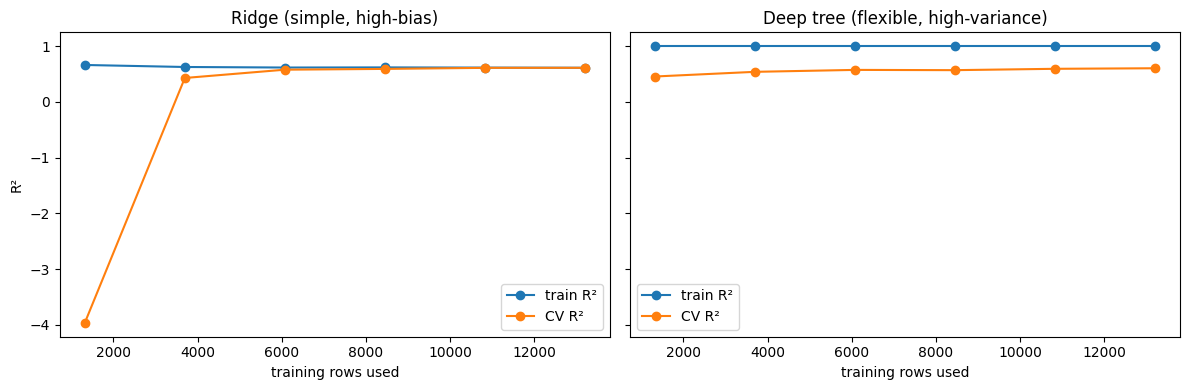

Ridge: the two curves hug each other early and plateau ~0.6 — HIGH BIAS.
  The current curve gives little evidence that substantially more
  same-distribution rows will help; richer features are the next test.
  (interactions, nonlinearities), not more of the same rows.
Deep tree: train R² pinned at ~1.0 (memorization), CV far below but still
  climbing with data — HIGH VARIANCE. More data genuinely helps, as would
  pruning (Section 4) or ensembling (Section 5).


In [21]:
# ============================================================
# Example B: learning curves — "would more data even help?"
# ============================================================
# learning_curve refits the model at increasing training sizes and returns
# train + CV scores at each size. The SHAPE of the two curves is a diagnosis:
#   curves converged, both mediocre -> HIGH BIAS: more data won't help;
#                                      you need better features / richer model.
#   persistent gap, CV still rising -> HIGH VARIANCE: more data (or more
#                                      regularization) WILL help.
from sklearn.tree import DecisionTreeRegressor

diagnosed = {
    'Ridge (simple, high-bias)':          Pipeline([('scaler', StandardScaler()),
                                                    ('model', Ridge(alpha=1.0))]),
    'Deep tree (flexible, high-variance)': DecisionTreeRegressor(max_depth=None,
                                                                 random_state=RANDOM_SEED),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, model) in zip(axes, diagnosed.items()):
    sizes, tr_scores, cv_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 6),
        cv=5, scoring='r2', n_jobs=-1,
    )
    ax.plot(sizes, tr_scores.mean(axis=1), marker='o', label='train R²')
    ax.plot(sizes, cv_scores.mean(axis=1), marker='o', label='CV R²')
    ax.set(title=name, xlabel='training rows used')
    ax.legend()
axes[0].set_ylabel('R²')
plt.tight_layout(); plt.show()

print("Ridge: the two curves hug each other early and plateau ~0.6 — HIGH BIAS.")
print("  The current curve gives little evidence that substantially more")
print("  same-distribution rows will help; richer features are the next test.")
print("  (interactions, nonlinearities), not more of the same rows.")
print("Deep tree: train R² pinned at ~1.0 (memorization), CV far below but still")
print("  climbing with data — HIGH VARIANCE. More data genuinely helps, as would")
print("  pruning (Section 4) or ensembling (Section 5).")

### Reading the output (Section 10, Example B)
- The two panels are the two canonical diagnoses, side by side, on the *same data*: Ridge's converged curves provide little evidence that more same-distribution data will help; the deep tree's yawning gap says "more data (or regularization) will pay."
- This is the highest-leverage plot in applied ML because data acquisition is usually the most expensive line item — the learning curve tells you *before* you spend.
- Connect the dots across the notebook: high variance is what pruning (S4), bagging (S5), shrinkage + early stopping (S6), and k-averaging (S3) all attack; high bias is what feature engineering (S9's lags) and richer models (S6, S7's kernels) attack.

### 🧠 Can you answer? (Section 10 — CV & Tuning)
1. **`best_score_` is optimistically biased even though every fold score was honestly out-of-fold. Explain the selection effect (max over noisy estimates), and why the bias grows with the number of candidates searched.**
2. **Nested cross-validation: what does the outer loop estimate that plain GridSearchCV cannot, and why is `grid.best_score_` NOT an unbiased estimate of the *tuned procedure's* generalization error?**
3. **After CV picks the winner, GridSearchCV refits it on ALL training data. Justify this refit — and name one situation (hint: early stopping / data-size-sensitive hyperparameters) where the refit can subtly invalidate the chosen hyperparameter.**
4. **Compute the number of model fits for: 5 alphas × 5 folds + final refit. Now add a second parameter with 6 values and switch to 10 folds. When does `RandomizedSearchCV` become the rational choice, and what does its key theoretical selling point say about high-dimensional search spaces (few parameters usually matter)?**
5. **K=2 vs K=10 vs leave-one-out: describe the bias-variance trade-off of the CV *estimate itself* as K grows, and why LOOCV's estimates are nearly unbiased but can have high variance (highly correlated folds).**
6. **Why does sklearn use `neg_root_mean_squared_error` instead of RMSE directly? What breaks in a generic maximize-the-score framework if lower-is-better metrics are passed as-is?**
7. **Explain exactly what goes wrong when KFold (shuffled) is applied to the Section 9 lag-feature dataset: which rows in a training fold contain near-copies of information about test-fold rows?**
8. **You run GridSearchCV weekly on refreshing data and always report `best_score_` to stakeholders. After a year, live performance persistently undershoots your reports. Name the two compounding biases at work and design the reporting protocol that fixes both.**
9. **A 2,000-combination grid on 800 rows with 10-fold CV produces a spectacular `best_score_` that fails on test. Connect this to multiple-comparisons: roughly what is the chance that at least one useless configuration 'wins big' by luck, and what defenses exist (fewer candidates, nested CV, one-standard-error rule)?**

## Mini Project Tracker

| Project | Topic | Dataset Benchmark | Model Baseline | Primary Metric | Status | Notes |
|---|---|---|---|---|---|---|
| **House Price Prediction** | Regression | California Housing | `Pipeline(Scaler, Ridge)` vs OLS/Lasso | RMSE / R² | Not Started | Skew check + residual homoscedasticity plot + Lasso sparsity path |
| **Customer Churn** | Classification (Imbalanced) | Synthetic Tabular | `Pipeline(ColumnTransformer, LogReg)` | F1 (validation-tuned threshold) / ROC-AUC | Not Started | Odds ratios + honest threshold tuning (val split or TunedThresholdClassifierCV) |
| **KNN Scaling Demo** | Classification | Wine | `Pipeline(Scaler, KNN)` | Accuracy | Not Started | Unscaled collapse + curse-of-dimensionality noise demo + closed-loop k |
| **Tree Interpretability** | Classification | Breast Cancer | `DecisionTreeClassifier(max_depth=3)` | Accuracy + Rule Extraction | Not Started | Depth sweep + ccp_alpha pruning path |
| **Credit Risk (RF)** | Classification (Imbalanced) | Synthetic `make_classification` | `RandomForestClassifier` (no scaler) | F1 / Classification Report | Not Started | MDI vs permutation importance (plotted) + OOB score |
| **Credit Risk (GB)** | Classification | Same Synthetic | `GradientBoostingClassifier` + early stop | F1 / ROC-AUC | Not Started | Head-to-head vs RF + staged-loss overfitting plot |
| **Digits SVM** | Classification | load_digits | `Pipeline(Scaler, PCA, SVC)` | Accuracy | Not Started | Linear vs RBF + C/gamma GridSearchCV |
| **News Text NB** | NLP Classification | 20 Newsgroups | `Pipeline(TfidfVectorizer, MultinomialNB)` | Accuracy / Confusion Matrix | Not Started | Alpha tuned by CV + top evidence words per class |
| **Sales Forecasting** | Time Series | Synthetic Sequence | `LinearRegression(Lags + Rolling)` | MAE vs Naive Baselines | Not Started | Beat persistence & seasonal naive + tree-extrapolation failure + TSSplit CV |
| **Tuning Workflow** | Meta / Validation | California Housing | `GridSearchCV(Pipeline)` | CV RMSE vs Test RMSE | Not Started | TimeSeriesSplit awareness + learning-curve bias/variance diagnosis |

## Experiment Log

| Date | Problem Context | Dataset Input | Model Configuration | Preprocessing Setup | Metric Tracked | Result | Next Progressive Steps |
|---|---|---|---|---|---|---|---|
| YYYY-MM-DD | House Price Prediction | California Housing | Ridge (alpha=1.0) | Standard Scaled | RMSE / R² | | Compare vs GridSearchCV-tuned alpha |
| YYYY-MM-DD | Customer Churn | Synthetic (8% positive) | LogReg (balanced) | ColumnTransformer | F1 @ validation-tuned threshold | | Try SMOTE resampling vs class weights |